# Tutorial 04: Binary Responses

## Lecture and Tutorial Learning Goals:
After completing this week's lecture and tutorial work, you will be able to:

1. Describe the logistic regression estimation procedure (binary response variable).
2. Discuss the relationship between linear regression and logistic regression. Discuss the consequences of modelling data more suitable for logistic regression models as a linear regression model.
3. Interpret the estimated coefficients and $p$-values in the logistic regression.
4. Write a computer script to estimate a logistic regression and perform model diagnostics. Interpret and communicate the results from that computer script.

In [1]:
# Run this cell before continuing.
library(tidyverse)
library(broom)
library(ISLR)
library(dplyr)
install.packages("arm")
library(arm)

source("tests_tutorial_04.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: lme4


arm (Version 1.15-3, built: 2026-4-15)


Working directory is /home/jovyan/work/stat-3

## Logistic Regression

Logistic Regressions are commonly used to model the probability of an event based on a set of observed covariates. 

Some summary points:

- the response variable is binary (takes only 2 values)

- the conditional expectation of a binary variable becomes a conditional probability, with takes values between 0 and 1 (range)

- we model a *function* of the conditional expectation to have a predicted response in the (0,1) range

- interpretations are in terms of log-odds (for the raw output) or in terms of odds (for exponentiated estimated coefficients)

#### Odds and odds ratios

The quantity $P(\left.Y_{i} = 1 \right| X_{i})/\left[1-P(\left.Y_{i} = 1 \right| X_{i})\right] = p_i/(1-p_i)$ is called <font color='darkred'>**odds of success**</font>

> Note the relation between probability of success and probability of failure, and think what would be the odds of failure.

<font color='darkred'>**Odds ratios**</font> are commonly used to compare odds of success for different groups:

For example:

- $\text{odds}_F = e^\beta_0$ 

- $\text{odds}_M = 
e^{\beta_0 + \beta_1} = e^\beta_0 e^\beta_1$

Then, the **odds ratio** comparing these levels is 
$$\frac{\text{odds}_M}{\text{odds}_F} =
e^\beta_1$$


 

### Dataset

This tutorial will focus on the dataset `Default` from [*An Introduction to Statistical Learning*](https://www.statlearning.com/) (James et al., 2013). This is a dataset of $n = 10,000$ observations with the following variables:

- `default`: a binary response indicating whether the customer defaulted on their debt (`Yes` or `No`).
- `student`: a binary input variable indicating whether the customer is a student (`Yes` or `No`).
- `balance`: a continuous input variable indicating the remaining average balance of the customer's credit card (after the monthly payment).
- `income`: a continuous input variable indicating the customer's income.

In [2]:
head(Default)

,default,student,balance,income
,<fct>,<fct>,<dbl>,<dbl>
1,No,No,729.5265,44361.625
2,No,Yes,817.1804,12106.135
3,No,No,1073.5492,31767.139
4,No,No,529.2506,35704.494
5,No,No,785.6559,38463.496
6,No,Yes,919.5885,7491.559


### 1. Estimation

Let's estimate the logistic regression given the data collected using *Maximum Likelihood Estimation (MLE)*. 

**Question 1.1:**
<br>{points: 1}

To fit a logistic model, we can use the function `glm()` and its argument `family = binomial` (required to specify the binary nature of the response). 

> The arguments of `glm()` are analogous to those of `lm()` (`formula` and `data`) with the addition of `family = ...`, to specify the distribution of the response variable.

Now, let's put this into practice. We'll estimate a binary logistic regression utilizing the function `glm()` with `default` as the response, and `student` as the input variable. The dataset is `Default`.
    
Store the model in an object named `default_logistic_student`. 

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [3]:
set.seed(200) #DO NOT CHANGE

# default_logistic_student <- 
#   ...(formula = ...,
#       data = ...,
#       family = ...)


# your code here
default_logistic_student <- 
  glm(formula = default ~ student,
      data = Default,
      family = binomial)

summary(default_logistic_student)


Call:
glm(formula = default ~ student, family = binomial, data = Default)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -3.50413    0.07071  -49.55  < 2e-16 ***
studentYes   0.40489    0.11502    3.52 0.000431 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2920.6  on 9999  degrees of freedom
Residual deviance: 2908.7  on 9998  degrees of freedom
AIC: 2912.7

Number of Fisher Scoring iterations: 6


In [4]:
test_1.1()

Test passed 🎉
Test passed 🥳
Test passed 🎊
[1] "Success!"


You can also get the exponentiated coefficients with the argument `exponentiate = TRUE` in `tidy()`.

In [5]:
default_logistic_student %>% 
    tidy(exponentiate = TRUE) 

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.03007299,0.07071301,-49.554219,0.0000000000
studentYes,1.49913321,0.11501883,3.520181,0.0004312529


**Note**:  recall that the `std.error` column still refers to the non-exponentiated estimators, e.g., it refers to $\hat{\beta}_0$ not $e^{\hat{\beta}_0}$

**Question 1.2**
<br>{points: 1}

Considering the estimated model `default_logistic_student`, what is the correct interpretation of the  $\hat{\beta}_\textit{student}$?

**A.** The estimated odds of default are $49.9\%$ higher for non-student customers than for student customers.

**B.** The estimated odds of default are $49.9\%$ higher for student customers than for non-student customers.

**C.** The estimated odds of default are $40.5\%$ higher for non-student customers than student customers.

**D.** The estimated odds of default are $40.5\%$ higher for student customers than non-student customers.

*Assign your answer to the object `answer1.2` (character type surrounded by quotes).*

In [6]:
# answer1.2 <- ...

# your code here
answer1.2 <- "B"

In [7]:
test_1.2()

Test passed 🎊
Test passed 🌈
Test passed 🌈
[1] "Success!"


#### Multiple covariates

As we learned in MLR, a logistic regression can have multiple covariates of differnet types. The interpretation of their coefficients are analogous, except that in the case of the logistic regression changes in the covariates are associated with changes in log odds (raw results) or in odds (exponentiated results).

Note that in the following questions we use different possible interpretations for the estimated coefficients of a logistic regression. 

**Question 1.3:**
<br>{points: 1}

Let us use the function `glm()` with `family = binomial` to estimate an *additive* logistic model with `default` as the response, and `student`, `balance`, and `income` as input variables (in that order), from the `Default` dataset.
    
Store the model in an object named `default_logistic_multiple`. 

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [8]:
# default_logistic_multiple <- 
#   ...(...,
#       ...,
#       ...)

# your code here
default_logistic_multiple <- 
  glm(formula=default ~ student + balance + income,
      data=Default,
      family=binomial)

default_logistic_multiple %>%
    tidy() %>% 
    mutate_if(is.numeric, round, 3)

default_logistic_multiple %>%
    tidy(exponentiate = TRUE) %>% 
    mutate_if(is.numeric, round, 3)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-10.869,0.492,-22.080,0.000
studentYes,-0.647,0.236,-2.738,0.006
balance,0.006,0.000,24.738,0.000
income,0.000,0.000,0.370,0.712


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000,0.492,-22.080,0.000
studentYes,0.524,0.236,-2.738,0.006
balance,1.006,0.000,24.738,0.000
income,1.000,0.000,0.370,0.712


In [9]:
test_1.3()

Test passed 🥇
Test passed 🥳
Test passed 🥳
[1] "Success!"


**Question 1.4**
<br>{points: 1}

Considering the estimated `default_logistic_multiple` model, which is (are) correct interpretation(s) of the  $\hat{\beta}_\textit{student}$?

**A.** Since $1 / 0.524 = 1.908$, we estimate that the odds of *non-default* are $90.8\%$ higher for non-student customers than for student customers while keeping the rest of the input variables constant.

**B.** Since $1 / 0.524 = 1.908$, we estimate that the odds of *non-default* for student customers are $90.8$ while keeping the rest of the input variables constant.

**C.** Since $1 / 0.524 = 1.908$, we estimate that the odds of *non-default* are $90.8\%$ higher for student customers than for non-student customers while keeping the rest of the input variables constant.

**D.** Since $1 / 0.524 = 1.908$, we estimate that the odds of *default* are $90.8\%$ higher for student custormers than for non-student customers while keeping the rest of the input variables constant.

**E.** Since $0.524 - 1 = - 0.476$, we estimate that the odds of *default* decline $47.6\%$ for non-student customers while keeping the rest of the input variables constant.

**F.** Since $0.524 - 1 = - 0.476$, we estimate that the odds of *default* decline $47.6\%$ for non-student customers while keeping the rest of the input variables constant.

*Assign your answer to the object `answer1.4`. Your answers have to be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., "ABCD" indicates you are selecting the first four options).*

In [10]:
# answer1.4 <- ...

# your code here
answer1.4 <- "CF"

In [11]:
test_1.4()

Test passed 🎉
Test passed 😸
Test passed 😸
[1] "Success!"


**Question 1.5**
<br>{points: 1}

How would you interprete the coefficient of `balance` from the estimated `default_logistic_multiple` model?

> Note: provide an interpretation based on odds, *not* log odds

> *While holding both student status and income constant, an increase in balance of someone's credit card by 1 dollar is associated with the odds of defaulting on their debt being multiplied by `1.006` (i.e. the odds increase by 0.6%).*

### 2. Inference

We can also assess whether an input variable is associated with the logarithm of the odds by by examining whether the estimated coefficient $\hat{\beta}_j$ is statistically significant. In other words, we can use the estimated model to conduct a hypothesis test and make inferences about population parameters ($\beta_j$). 

**Question 2.1**
<br>{points: 1}

Report the estimated coefficients, their estimated standard errors, and corresponding $p$-values by calling `tidy()` on `default_logistic_multiple`. Include the corresponding asymptotic 95% confidence intervals. 

Store the results in the variable `default_logistic_multiple_results`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [12]:
# default_logistic_multiple_results <- 
#    ... %>%
#    ...(conf.int = TRUE) 

# your code here
default_logistic_multiple_results <- 
   default_logistic_multiple %>%
   tidy(conf.int = TRUE) 

default_logistic_multiple_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.086905e+01,4.922555e-01,-22.080088,4.911280e-108,-1.185902e+01,-9.928174e+00
studentYes,-6.467758e-01,2.362525e-01,-2.737646,6.188063e-03,-1.109018e+00,-1.822147e-01
balance,5.736505e-03,2.318945e-04,24.737563,4.219578e-135,5.294898e-03,6.204587e-03
income,3.033450e-06,8.202615e-06,0.369815,7.115203e-01,-1.304712e-05,1.912447e-05


In [13]:
test_2.1()

Test passed 🌈
Test passed 🥇
Test passed 🌈
Test passed 🎉
Test passed 😸
[1] "Success!"


**Question 2.2**
<br>{points: 1}

Use `tidy()` and the estimated model stored in `default_logistic_multiple` to obtain estimated coefficients and 95% confident intervals for the association between each variable and the *odds* of being in default. 

Store the results in the variable `default_logistic_odds_results`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [14]:
# default_logistic_odds_results <- 
#    default_logistic_multiple %>%
#    ... %>%
#    mutate_if(is.numeric, round, 6)

# your code here
default_logistic_odds_results <- 
   default_logistic_multiple %>%
   tidy(conf.int = TRUE, exponentiate=TRUE) %>%
   mutate_if(is.numeric, round, 6)

default_logistic_odds_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.000019,0.492256,-22.080088,0.000000,0.000007,0.000049
studentYes,0.523732,0.236253,-2.737646,0.006188,0.329883,0.833422
balance,1.005753,0.000232,24.737563,0.000000,1.005309,1.006224
income,1.000003,0.000008,0.369815,0.711520,0.999987,1.000019


In [15]:
test_2.2()

Test passed 🌈
Test passed 🎊
Test passed 🎉
Test passed 🥇
Test passed 🎉
[1] "Success!"


**Question 2.3**
<br>{points: 1}

Using a **significance level $\alpha = 0.05$**, which inputs are statistically associated with the odds of default in `default_logistic_odds_results`?

**A.** The categorical input `student`.

**B.** The continuous input `balance`.

**C.** The continuous input `income`.

> Note: statistically association means that the corresponding estimated coefficient is statistically significant at level $\alpha$.

*Assign your answers to the object `answer2.3`. Your answers must be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., `"ABC"` indicates you are selecting the three options).*

In [16]:
# answer2.3 <- 

# your code here
answer2.3 <- "AB"

In [17]:
test_2.3()

Test passed 🎉
Test passed 🎊
[1] "Success!"


### 3. Prediction

Besides inference, we can use an estimated logistic regression model to predict probability of success in new or future observations. 

For example, suppose we want to predict the odds of a student who has a credit card balance of \\$2200 and an income of \\$35000 to be in default relative to not being in default.

Mathematically, our predicted log odds will be 

\begin{gather*} 
\log \bigg( \frac{\hat{p}_\texttt{default}}{1 - \hat{p}_\texttt{default}}\bigg) = \underbrace{-10.869045}_{\hat{\beta}_0} - \underbrace{0.646776}_{\hat{\beta}_1} \times 1 + \underbrace{0.005737}_{\hat{\beta}_2} \times 2200 + \underbrace{0.000003}_{\hat{\beta}_2} \times 35000= 1.21 \\
\end{gather*}

Next, by taking the exponential on both sides of the equation, we obtain our predicted *odds*: 

$$
\frac{\hat{p}_\texttt{default}}{1 - \hat{p}_\texttt{default}} = e^{1.21} = 3.36.
$$

Finally, solving the above for $\hat{p}_\texttt{default}$, we obtain our predicted probability of default

$$
\hat{p}_\texttt{default} = 3.36/4.36 = 0.7706
$$

**Question 3.1**
<br>{points: 1}

Using `predict` and `default_logistic_multiple`, obtain the **odds of default** predicted above.

*Hint: Check the argument `type` when coding this prediction.*

*Assign your answer to the object `answer3.1`. Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [18]:
# answer3.1 <- 
#     ...(...,
#         tibble(student = ..., balance = ..., income = ...),
#         type = ...) %>%
#     ... # how did you obtain the predicted odds above? 

# your code here
answer3.1 <- 
    predict(default_logistic_multiple,
        tibble(student = "Yes", balance = 2200, income = 35000),
        type = "link") %>%
    exp() # how did you obtain the predicted odds above? 

answer3.1

1 
3.355703

In [19]:
test_3.1()

Test passed 🌈
Test passed 🎉
Test passed 😸
[1] "Success!"


**Question 3.2**
<br>{points: 1}

We can also predict *probabilities* for classification purposes, i.e., whether the customer will default. Using the function `predict()` with the object `default_logistic_multiple`, obtain the estimated probability that a given customer will default. This customer is a `student` who has a credit card `balance `2200` and income of `35000`.


*Hint: Check the argument `type` when coding this prediction.*

*Assign your answer to the object `answer3.2`. Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [20]:
# answer3.2 <- 
#     ...(...,
#         tibble(...),
#         type = ...)

# your code here
answer3.2 <- 
    predict(default_logistic_multiple,
        tibble(student="Yes", balance=2200, income=35000),
        type = "response")

answer3.2

1 
0.7704159

In [21]:
test_3.2()

Test passed 😸
Test passed 😸
Test passed 🥇
[1] "Success!"


### Fitted Values

Predicted values for *in-sample* observations are usually called *fitted* values and they are stored as an object of the estimated model (check `objects(default_logistic_multiple)`). In the next question, you will explore different ways of obtaining *fitted* values. 

But as noted in the previous questions, we can get different types of fitted values since the same model can be used to predict *probabilities, odds, and log odds* (linear component). 

It is important that you know which values you obtain when using different functions in R.

**Question 3.3**
<br>{points: 1}

Using the function `augment()` with the object `default_logistic_multiple`, you can obtain fitted values and residuals along with the original data points. The `augment()` function adds many columns that we are not going to use at this time so we are selecting only a subset of the columns. 

Next, we will add the predicted probability to this tibble that are stored in the object `default_logistic_multiple` under the name `fitted`. Call the column `pred_prob`.

Using this predicted probability you can calculate the logit (log odds) for each response, i.e., $\log(p/(1-p))$. Call the column `pred_line`, since this correspond to the estimated linear component of the model.

Add the predicted odds to the tibble and call the column `pred_odds`.

*Assign your answer to the object `default_logistic_fitted`. Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [22]:
# default_logistic_fitted <- default_logistic_multiple %>%
#               ...() %>%
#               dplyr::select(colnames(Default),.fitted) %>%
#               mutate(pred_prob = ...$fitted,
#                        pred_line = ...,
#                        pred_odds = ...(.fitted))

# your code here
default_logistic_fitted <- default_logistic_multiple %>%
              augment() %>%
              dplyr::select(colnames(Default),.fitted) %>%
              mutate(pred_prob = default_logistic_multiple$fitted,
                       pred_line = log(pred_prob/(1-pred_prob)),
                       pred_odds = exp(.fitted))

head(default_logistic_fitted,3)

default,student,balance,income,.fitted,pred_prob,pred_line,pred_odds
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
No,No,729.5265,44361.63,-6.549544,0.001428724,-6.549544,0.001430768
No,Yes,817.1804,12106.13,-6.791338,0.001122204,-6.791338,0.001123465
No,No,1073.5492,31767.14,-4.614261,0.009812272,-4.614261,0.009909506


In [23]:
test_3.3()

Test passed 😀
Test passed 🎉
Test passed 😸
Test passed 🎊
[1] "Success!"


**Question 3.4**
<br>{points: 1}

Based on the results obtained in `default_logistic_fitted`, which of the following observations are correct?

**A.** The column `.fitted` in the output of `augment()` contains the predicted probabilities of default for each customer in the dataset.

**B.** The column `.fitted` in the output of `augment()` contains the predicted odds of default for each customer in the dataset.

**C.** The element `fitted` in `default_logistic_multiple` contains the predicted probabilities of default for each customer in the dataset.

**D.** The element `fitted` in `default_logistic_multiple` contains the predicted odds of default for each customer in the dataset.

**E.** The predicted odds can be calculated from `default_logistic_multiple$fitted` or `.fitted`.

**F.** The column `.fitted` computes the linear predictor used in the logistic regression to model the log odds.

*Assign your answers to the object answer3.4. Your answers must be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., "ABC" indicates you are selecting the first three options).*

In [24]:
# answer3.4 <- 

# your code here
answer3.4 <- "CEF"

In [25]:
test_3.4()

Test passed 🥇
Test passed 🥳
Test passed 😀
[1] "Success!"


### 4. Residuals

Different residuals have been proposed for GLM. The **raw residuals** are, as usual, the differences between the observed and the fitted values. 

However, in most GLMs the observations have different variances. Thus, residuals are not comparable and should be adjusted. Below is a list of other residuals suggested for GLMs.

Definitions of each of these type of residuals can be found [here](https://online.stat.psu.edu/stat501/lesson/15/15.4) 

**Question 4.1: Residuals**
<br>{points: 1}

Fitted values are important to compute *residuals*, the difference between the observed and the predicted values by the estimated model. We'll learn more about residuals later in the course. But, which type of fitted values we need to use??

Since the observations are binary values, 0 and 1, the residuals are calculated using the predicted probabilities, i.e., `your_model$fitted`. However, there are many type of residuals as well to account for the difference in variance of each response.

In this question, we'll focus on the *residuals*.

The `augment()` function also computes residuals, but which version?? Let's start by getting the residuals computed by `augment()`.

Next, we will add the residuals using the function `residuals` on the estimated model `default_logistic_multiple`. Note that this function computes different type of residuals, add type `response`, `pearson` and `deviance` to the tibble.

Compute the raw and the Pearson's residuals by hand to check your understanding.

Finally, add the standardized residuals using the function `rstandard` on the estimated model `default_logistic_multiple`.

*Assign your answer to the object `default_logistic_residuals`. Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [26]:
# default_logistic_residuals <- ... %>%
#               ...() %>%
#               dplyr::select(colnames(Default),.fitted, .resid,.std.resid) %>%
#               mutate(pred_prob = ...,
#                      response = ...(... == "Yes", 1, 0),
#                      resid_raw = residuals(..., type = "response"),
#                      raw_byhand = ... - ...,
#                      resid_deviance = residuals(default_logistic_multiple),
#                      resid_pearson =...(default_logistic_multiple,"..."),
#                      pearson_byhand = .../sqrt(...),
#                      resid_standardized =rstandard(...))

# your code here
default_logistic_residuals <- default_logistic_multiple %>%
              augment() %>%
              dplyr::select(colnames(Default),.fitted, .resid,.std.resid) %>%
              mutate(pred_prob = default_logistic_multiple$fitted,
                     response = if_else(default == "Yes", 1, 0),
                     resid_raw = residuals(default_logistic_multiple, type = "response"),
                     raw_byhand = response - pred_prob,
                     resid_deviance = residuals(default_logistic_multiple),
                     resid_pearson =residuals(default_logistic_multiple,"pearson"),
                     pearson_byhand = (response - pred_prob) /sqrt(pred_prob * (1-pred_prob)),
                     resid_standardized =rstandard(default_logistic_multiple))

head(default_logistic_residuals,3)

default,student,balance,income,.fitted,.resid,.std.resid,pred_prob,response,resid_raw,raw_byhand,resid_deviance,resid_pearson,pearson_byhand,resid_standardized
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
No,No,729.5265,44361.63,-6.549544,-0.05347421,-0.05347591,0.001428724,0,-0.001428724,-0.001428724,-0.05347421,-0.03782550,-0.03782550,-0.05347591
No,Yes,817.1804,12106.13,-6.791338,-0.04738848,-0.04739004,0.001122204,0,-0.001122204,-0.001122204,-0.04738848,-0.03351812,-0.03351812,-0.04739004
No,No,1073.5492,31767.14,-4.614261,-0.14043311,-0.14044957,0.009812272,0,-0.009812272,-0.009812272,-0.14043311,-0.09954650,-0.09954650,-0.14044957


In [27]:
test_4.1()

Test passed 🎉
Test passed 🌈
Test passed 🎉
Test passed 🌈
[1] "Success!"


**Question 4.2**
<br>{points: 1}

Based on the results obtained in `default_logistic_residuals`, which of the following observations are correct?

**A.** The column `.resid` in the output of `augment()` contains the values of the response minus the predicted probabilities of default for each customer in the dataset.

**B.** The function `residuals()` computes as a default the values of the response minus the predicted probabilities of default for each customer in the dataset.

**C.** The column `.resid` in the output of `augment()` contains the values of deviance residuals.

**D.** The function `residuals()` computes as a default the values of the deviance residuals.

**E.** The raw and Pearson's residuals can be computed using function `residuals()` changing the argument `type`.

*Assign your answers to the object answer4.2. Your answers must be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., "ABC" indicates you are selecting the first three options).*

In [28]:
# answer4.2 <- 

# your code here
answer4.2 <- "CDE"

In [29]:
test_4.2()

Test passed 🎉
Test passed 😸
Test passed 🌈
[1] "Success!"


**Question 4.3**
<br>{points: 1}

The plot of the residuals are usually hard to interpret for models with discrete responses. Thus, plots with binned residuals have been proposed instead.

Use the function `binnedplot()` in the package `arm` to plot a binnedplot of the residuals. Call the plot `residual_plot`.

> Note 1: the argument `nclass` regulates the number of bins used. In this questions we are using the default argument `nclass` but you can try to change it other values, e.g., `nclass = 10` will show less points.

> Note 2: it is recommended to use the residuals and the fitted values in the scale of the response for this plot, i.e., raw residuals and predicted probabilities.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

NULL

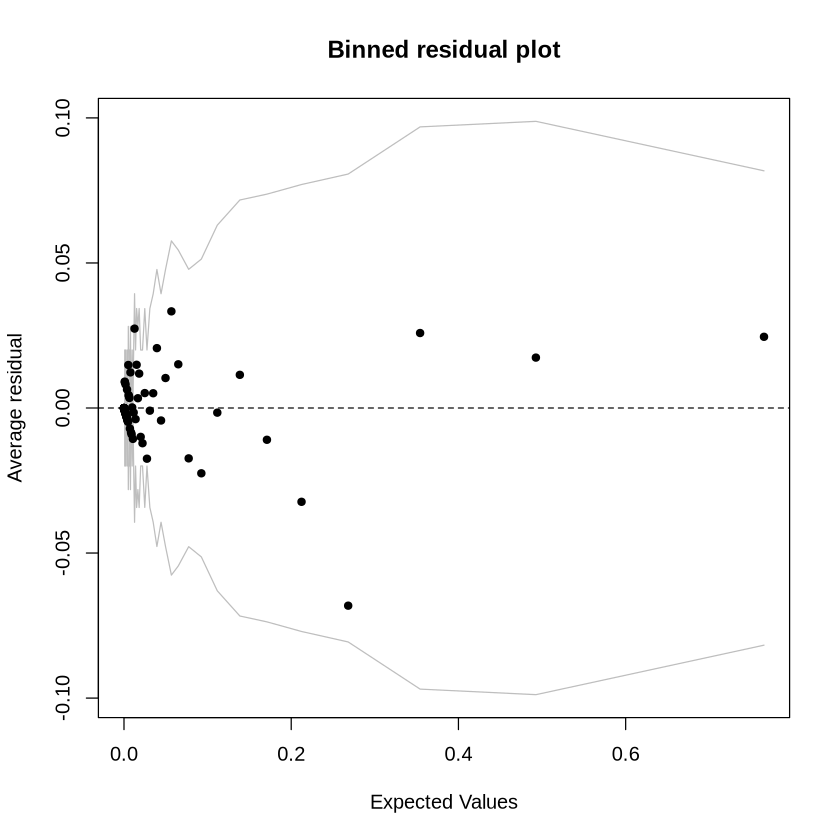

In [30]:
# y_resid <- default_logistic_residuals$...
# x_fit <- ...

# residual_plot <- ...(x_fit, y_resid)

# your code here
y_resid <- default_logistic_residuals$resid_raw
x_fit <- default_logistic_residuals$pred_prob

residual_plot <- binnedplot(x_fit, y_resid)

residual_plot

In [31]:
test_4.3()

Test passed 🎊
Test passed 😸
[1] "Success!"


### 5. Overdispersion

The variance of a binary response variable is a function of the mean: $p(1-p)$. This means that the estimate of the mean also provides an estimate of the variance of the response. 

Since the logistic regression is built assuming that the response is *Bernoulli*, the estimated $\hat{p}$ conditions the estimated variance of the response to be $\hat{p}(1-\hat{p})$.  

Unfortunately, in real applications, even in situations where the model seems to be estimating the mean well, the data's variability is not quite compatible with the model's assumed variance. <font style='color: darkred'>This misspecification in the variance affects the SE of the coefficients, not their estimates.</font>

A way around this problem is to estimate a dispersion parameter, usually called $\phi$, to correct the standard error of our estimators. An easy implementation is to change the `family` argument to a `quasibinomial`. Let's see an example.  

In [32]:
default_logistic_quasi <- summary(glm(
    formula = default ~ student + balance + income,
    data = Default,
    family = quasibinomial))

default_logistic_quasi


Call:
glm(formula = default ~ student + balance + income, family = quasibinomial, 
    data = Default)

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.087e+01  4.121e-01 -26.376  < 2e-16 ***
studentYes  -6.468e-01  1.978e-01  -3.270  0.00108 ** 
balance      5.737e-03  1.941e-04  29.551  < 2e-16 ***
income       3.033e-06  6.867e-06   0.442  0.65867    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasibinomial family taken to be 0.7007742)

    Null deviance: 2920.6  on 9999  degrees of freedom
Residual deviance: 1571.5  on 9996  degrees of freedom
AIC: NA

Number of Fisher Scoring iterations: 8


In [33]:
#Run this cell for a reference to previous model
tidy(default_logistic_multiple)

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-1.086905e+01,4.922555e-01,-22.080088,4.911280e-108
studentYes,-6.467758e-01,2.362525e-01,-2.737646,6.188063e-03
balance,5.736505e-03,2.318945e-04,24.737563,4.219578e-135
income,3.033450e-06,8.202615e-06,0.369815,7.115203e-01


**Question 5.1**
<br>{points: 1}

Compare the estimated coefficients and the standard errors of the regression coefficients of the models `default_logistic_multiple` and `default_logistic_quasi`. Have these changed? 

What is the estimated overdispersion parameter in this case? Would you consider the original model `default_logistic_multiple` appropriate based on the new results?

> *The estimated coefficients are the same between both the `default_logistic_multiple` and `default_logistic_quasi` models. However, the standard errors for the regression coefficients are greater in the `default_logistic_multiple` model. This is an example of how misspecification in the variance affects the SE of the coefficients rather than their estimates.*
>
> *The estimated overdispersion parameter in this case is `0.701` which is below the `1.0` threshold, therefore indicating underdispersion. Consequently, the original model `default_logistic_multiple` would be considered appropriate since the overdispersion parameter is under 1 therefore indicating that the data actually varies less than what is assumed by the binomial distribution. Therefore, the standard errors are too large in the original data because the original model's assumptions overestimate the variance of the data.*